# Laboratorio 6 — Análisis de redes sociales de YouTube

Este notebook contiene la carga, integración, diagnóstico de calidad y preprocesamiento de los datos de YouTube. El análisis se mantiene en un único archivo reproducible.

In [1]:
from pathlib import Path
import ast
import json
import re
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display, Markdown

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)
RAIZ_PROYECTO = Path.cwd() if (Path.cwd() / 'data').exists() else Path.cwd().parent
ARCHIVO_VIDEOS = RAIZ_PROYECTO / 'data' / 'youtube_videos.csv'
ARCHIVO_COMENTARIOS = RAIZ_PROYECTO / 'data' / 'youtube_comments.csv'
assert ARCHIVO_VIDEOS.exists() and ARCHIVO_COMENTARIOS.exists(), 'Ejecute el notebook desde la carpeta que contiene los CSV.'

## 1. Carga y comprensión de los datos

- **`youtube_videos.csv`:** cada fila es un video; su llave primaria es `video_id`.
- **`youtube_comments.csv`:** cada fila es un comentario principal; su llave primaria es `comment_id`.
- **Relación:** `video_id` es llave foránea en comentarios y relaciona muchos comentarios con un video. Un canal publica videos (`channel_id`) y un autor de comentario se identifica con `author_channel_id`; los nombres y handles son etiquetas visibles, no identificadores estables.
- `category` clasifica el video según YouTube. `source_query` documenta cómo fue recolectado y no debe asumirse como tema definitivo.

In [2]:
videos = pd.read_csv(ARCHIVO_VIDEOS, encoding='utf-8-sig')
comentarios = pd.read_csv(ARCHIVO_COMENTARIOS, encoding='utf-8-sig')

resumen_carga = pd.DataFrame({
    'dataset': ['youtube_videos.csv', 'youtube_comments.csv'],
    'unidad_de_observacion': ['video de YouTube', 'comentario principal de YouTube'],
    'llave_primaria': ['video_id', 'comment_id'],
    'filas': [len(videos), len(comentarios)],
    'columnas': [videos.shape[1], comentarios.shape[1]]
})
display(resumen_carga)
display(Markdown('### Muestra de videos'))
display(videos.head(3))
display(Markdown('### Muestra de comentarios'))
display(comentarios.head(3))

,dataset,unidad_de_observacion,llave_primaria,filas,columnas
0,youtube_videos.csv,video de YouTube,video_id,293,20
1,youtube_comments.csv,comentario principal de YouTube,comment_id,406,17


### Muestra de videos

,video_id,title,channel_name,channel_id,source_query,source_group,dataset_sources,channel_handle,published_time,view_count_text,description_snippet,video_url,query_hits,keywords,description,view_count,publish_date,upload_date,category,owner_handle
0,-5puKGEqcUc,INSIVUMEH pronostica incremento de lluvias para el fin de semana en Guatemala,T13 Noticias Guatemala,UCq0Cm-3SKthEySQc2JZBi1A,guatemala lluvias,topic,youtube_guatemala.csv | youtube_guatemala_lab.csv | youtube_guatemala_plus.csv,/@T13NoticiasGuatemala,hace 2 días,"2,390 vistas",El Departamento de Pronóstico de INSIVUMEH prevé un incremento en las lluvias durante este fin d...,https://www.youtube.com/watch?v=-5puKGEqcUc,"[""guatemala lluvias""]","[""Canícula prolongada"", ""Chapin tv"", ""Fenómeno del Niño"", ""Guatemala"", ""Lluvias en Guatemala"", ""...",El Departamento de Pronóstico de INSIVUMEH prevé un incremento en las lluvias durante este fin d...,2357,2026-08-28T22:00:20-07:00,2026-08-28T22:00:20-07:00,News & Politics,/@T13NoticiasGuatemala
1,-E7OPOLjMug,BERNARDO ARÉVALO CALIFICA CAMBIO EN EL MP COMO EL FIN DE UNA ETAPA DE DETERIORO INSTITUCIONAL,IDocumenta,UCgItjn_ZWFWcv1MlpKIkqgQ,@GobiernodelaRepublicadeGuatema,topic,youtube_target_channels.csv,/@iDocumenta,hace 3 meses,4 vistas,"El presidente de Guatemala, Bernardo Arévalo, calificó el cambio de fiscal general y jefe del Mi...",https://www.youtube.com/watch?v=-E7OPOLjMug,"[""@GobiernodelaRepublicadeGuatema""]",[],"El presidente de Guatemala, Bernardo Arévalo, calificó el cambio de fiscal general y jefe del Mi...",4,2026-05-13T16:00:03-07:00,2026-05-13T16:00:03-07:00,People & Blogs,/@iDocumenta
2,-KDglrIzRKo,¡HISTÓRICO! Mexico recupera petróleo robado por Guatemala... 🔔,México Poder,UC-DpoeBbCMOMOH1-j71KPqA,guatemala noticias,topic,youtube_guatemala.csv | youtube_guatemala_lab.csv | youtube_guatemala_plus.csv,/@M%C3%A9xicoPoder,hace 1 día,"29,736 vistas",México #PetróleoMexicano #SoberaníaEnergética #Pemex #NoticiasMéxico #FronteraSur #Huachicol #Gu...,https://www.youtube.com/watch?v=-KDglrIzRKo,"[""guatemala noticias""]","[""Mexico recupera petroleo"", ""petroleo robado Guatemala"", ""huachicol frontera sur"", ""Pemex notic...",#México #PetróleoMexicano #SoberaníaEnergética #Pemex #NoticiasMéxico #FronteraSur #Huachicol #G...,29736,2026-08-29T17:00:38-07:00,2026-08-29T17:00:38-07:00,People & Blogs,/@M%C3%A9xicoPoder


### Muestra de comentarios

,video_id,comment_id,video_title,channel_name,channel_id,author_name,author_channel_id,text,source_query,source_group,dataset_sources,author_handle,published_text,like_count_text,reply_count,is_pinned,viewer_rating
0,j43HgwYFKfk,Ugw-J65a1iYL9hqhELh4AaABAg,La cooptación de Walter Mazariegos en la USAC,Quorum,UCE4rsXcgDb6e1-a9iTbWzfg,@MarcosCarillo-b1r,UCdFlugHJJa4l3YqWuNRmvXw,Ese corrupto amigo de la vieja fiscal los tengo que verbose en la carcel,@quorumgt,topic,j43HgwYFKfk_out_comments.csv | quorum_complete_comments.csv | youtube_guatemala_plus_comments.csv,/@MarcosCarillo-b1r,hace 6 meses,,0,False,NaN
1,06mFNPU0aB8,Ugw-ZT9t9wU2V-tCaUZ4AaABAg,Capturan a presuntos delincuentes disfrazados de mujer señalados de cometer asalto,Noti7,UCVpSRoZgngfSL03Nlbjtq9A,@RaulPerez-cw2vi,UCvl1tzQeBeGy6efPTRJXSCw,"Están jóvenes porque no buscan un trabajo, tuvieron suerte que no hay policías que le gusta del...",guatemala noticias,topic,youtube_guatemala_comments.csv | youtube_guatemala_plus_comments.csv,/@RaulPerez-cw2vi,hace 2 semanas,,0,False,NaN
2,j43HgwYFKfk,Ugw0xaOb2CYXXoudtwJ4AaABAg,La cooptación de Walter Mazariegos en la USAC,Quorum,UCE4rsXcgDb6e1-a9iTbWzfg,@iamjimalesssa,UCRAquv8el-tQ30bN7MlmySQ,"Me dejaron con ganas de demandar la ilegalidad de las reuniones virtuales, esto no es una maquila",@quorumgt,topic,j43HgwYFKfk_out_comments.csv | quorum_complete_comments.csv | youtube_guatemala_plus_comments.csv,/@iamjimalesssa,hace 1 año,4,0,False,NaN


## 2. Diagnóstico inicial de calidad

Se revisan dimensiones, tipos, valores faltantes, duplicados, columnas constantes, valores extremos de conteos y consistencia de los identificadores. Los duplicados de texto no se eliminan automáticamente: dos usuarios pueden publicar el mismo contenido y siguen siendo observaciones distintas.

In [3]:
def perfil_calidad(nombre, df, id_cols):
    constantes = df.columns[df.nunique(dropna=False).eq(1)].tolist()
    return pd.DataFrame([{
        'dataset': nombre, 'filas': len(df), 'columnas': df.shape[1],
        'duplicados_fila': int(df.duplicated().sum()),
        'variables_constantes': ', '.join(constantes) if constantes else 'ninguna',
        **{f'{col}_nulos': int(df[col].isna().sum()) for col in id_cols},
        **{f'{col}_duplicados': int(df[col].duplicated().sum()) for col in id_cols}
    }])

diagnostico = pd.concat([
    perfil_calidad('videos', videos, ['video_id', 'channel_id']),
    perfil_calidad('comentarios', comentarios, ['comment_id', 'video_id', 'author_channel_id'])
], ignore_index=True)
display(diagnostico)

faltantes = pd.concat([
    videos.isna().sum().rename('videos'),
    comentarios.isna().sum().rename('comentarios')
], axis=1).fillna(0).astype(int)
faltantes = faltantes.loc[faltantes.sum(axis=1) > 0]
display(Markdown('### Variables con valores faltantes'))
display(faltantes)

display(Markdown('### Tipos observados'))
display(pd.DataFrame({'tipo_videos': videos.dtypes.astype(str)}))
display(pd.DataFrame({'tipo_comentarios': comentarios.dtypes.astype(str)}))

,dataset,filas,columnas,duplicados_fila,variables_constantes,video_id_nulos,channel_id_nulos,video_id_duplicados,channel_id_duplicados,comment_id_nulos,author_channel_id_nulos,comment_id_duplicados,author_channel_id_duplicados
0,videos,293,20,0,ninguna,0,0.0,0,196.0,NaN,NaN,NaN,NaN
1,comentarios,406,17,0,"is_pinned, viewer_rating",0,NaN,387,NaN,0.0,0.0,0.0,74.0


### Variables con valores faltantes

,videos,comentarios
published_time,13,0
view_count_text,13,0
description_snippet,25,0
description,26,0
viewer_rating,0,406


### Tipos observados

,tipo_videos
video_id,str
title,str
channel_name,str
channel_id,str
source_query,str
source_group,str
dataset_sources,str
channel_handle,str
published_time,str
view_count_text,str


,tipo_comentarios
video_id,str
comment_id,str
video_title,str
channel_name,str
channel_id,str
author_name,str
author_channel_id,str
text,str
source_query,str
source_group,str


In [4]:
consistencia = pd.DataFrame([
    {'relacion': 'channel_id → channel_name (videos)', 'IDs': videos.channel_id.nunique(), 'nombres_distintos_por_ID': int((videos.groupby('channel_id').channel_name.nunique() > 1).sum())},
    {'relacion': 'channel_id → channel_handle (videos)', 'IDs': videos.channel_id.nunique(), 'nombres_distintos_por_ID': int((videos.groupby('channel_id').channel_handle.nunique() > 1).sum())},
    {'relacion': 'author_channel_id → author_name', 'IDs': comentarios.author_channel_id.nunique(), 'nombres_distintos_por_ID': int((comentarios.groupby('author_channel_id').author_name.nunique() > 1).sum())},
    {'relacion': 'author_channel_id → author_handle', 'IDs': comentarios.author_channel_id.nunique(), 'nombres_distintos_por_ID': int((comentarios.groupby('author_channel_id').author_handle.nunique() > 1).sum())}
])
display(consistencia)

display(Markdown('### Variables que requieren precaución'))
display(pd.DataFrame([
    ['published_time / published_text', 'Son tiempos relativos; no se usan como fecha exacta.'],
    ['view_count_text / like_count_text', 'Son texto; se convierten a conteo numérico conservando el original.'],
    ['viewer_rating', 'Está vacío; no aporta análisis.'],
    ['is_pinned', 'Es constante; no discrimina observaciones.'],
    ['reply_count', 'Mide respuestas recibidas, no identifica autores ni aristas entre usuarios.'],
    ['source_query / source_group', 'Describen muestreo, no necesariamente el tema definitivo.']
], columns=['variable', 'tratamiento/precaución']))

,relacion,IDs,nombres_distintos_por_ID
0,channel_id → channel_name (videos),97,0
1,channel_id → channel_handle (videos),97,0
2,author_channel_id → author_name,332,0
3,author_channel_id → author_handle,332,0


### Variables que requieren precaución

,variable,tratamiento/precaución
0,published_time / published_text,Son tiempos relativos; no se usan como fecha exacta.
1,view_count_text / like_count_text,Son texto; se convierten a conteo numérico conservando el original.
2,viewer_rating,Está vacío; no aporta análisis.
3,is_pinned,Es constante; no discrimina observaciones.
4,reply_count,"Mide respuestas recibidas, no identifica autores ni aristas entre usuarios."
5,source_query / source_group,"Describen muestreo, no necesariamente el tema definitivo."


## 3. Normalización e integración

Los IDs se convierten a texto y se retiran espacios laterales, sin reemplazarlos por nombres. Se integra con una unión `many-to-one`: muchos comentarios pueden pertenecer a un único video. La validación evita una relación errónea si existieran `video_id` duplicados en la tabla de videos.

In [5]:
ID_VIDEOS = ['video_id', 'channel_id']
ID_COMENTARIOS = ['video_id', 'comment_id', 'channel_id', 'author_channel_id']
for columna in ID_VIDEOS:
    videos[columna] = videos[columna].astype('string').str.strip()
for columna in ID_COMENTARIOS:
    comentarios[columna] = comentarios[columna].astype('string').str.strip()

comentarios_integrados = comentarios.merge(
    videos, on='video_id', how='left', validate='many_to_one',
    suffixes=('_comentario', '_video'), indicator=True
)
asociados = int((comentarios_integrados['_merge'] == 'both').sum())
display(Markdown(f'**Resultado de integración:** {asociados} de {len(comentarios)} comentarios ({asociados / len(comentarios):.1%}) se asociaron con un video.'))
display(comentarios_integrados['_merge'].value_counts().rename_axis('resultado').reset_index(name='comentarios'))
comentarios_integrados = comentarios_integrados.drop(columns='_merge')

**Resultado de integración:** 406 de 406 comentarios (100.0%) se asociaron con un video.

,resultado,comentarios
0,both,406
1,left_only,0
2,right_only,0


## 4. Conversión de conteos y revisión de extremos

La función siguiente elimina etiquetas como `vistas`, espacios y separadores de miles. También admite abreviaturas `K` y `M`; valores vacíos o inválidos se convierten en faltantes. Se conserva siempre la columna textual original para auditoría.

,variable,minimo,mediana,maximo,faltantes
0,view_count_limpio,2.0,1175.0,8190449.0,0
1,like_count_limpio,1.0,2.0,405.0,189
2,reply_count,0.0,0.0,7.0,0


/tmp/ipykernel_1369125/1105213550.py:32: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(serie.dropna(), vert=True)
/tmp/ipykernel_1369125/1105213550.py:32: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(serie.dropna(), vert=True)
/tmp/ipykernel_1369125/1105213550.py:32: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(serie.dropna(), vert=True)


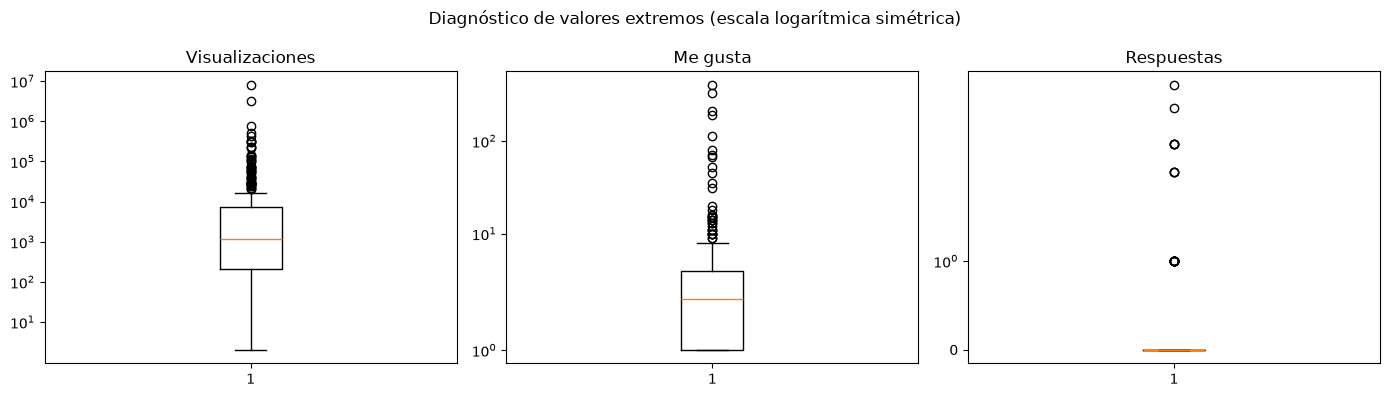

In [6]:
def convertir_conteo(valor):
    if pd.isna(valor) or not str(valor).strip():
        return np.nan
    texto = str(valor).lower().replace('vistas', '').replace('me gusta', '').strip()
    coincidencia = re.search(r'([\d.,]+)\s*([km]?)', texto)
    if not coincidencia:
        return np.nan
    numero, sufijo = coincidencia.groups()
    if re.search(r',\d{3}(?:\D|$)', numero):
        numero = numero.replace(',', '')
    else:
        numero = numero.replace(',', '.')
    try:
        return float(numero) * {'k': 1_000, 'm': 1_000_000}.get(sufijo, 1)
    except ValueError:
        return np.nan

videos['view_count_limpio'] = videos['view_count_text'].map(convertir_conteo).fillna(videos['view_count'])
comentarios['like_count_limpio'] = comentarios['like_count_text'].map(convertir_conteo)

conteos = pd.DataFrame({
    'variable': ['view_count_limpio', 'like_count_limpio', 'reply_count'],
    'minimo': [videos.view_count_limpio.min(), comentarios.like_count_limpio.min(), comentarios.reply_count.min()],
    'mediana': [videos.view_count_limpio.median(), comentarios.like_count_limpio.median(), comentarios.reply_count.median()],
    'maximo': [videos.view_count_limpio.max(), comentarios.like_count_limpio.max(), comentarios.reply_count.max()],
    'faltantes': [videos.view_count_limpio.isna().sum(), comentarios.like_count_limpio.isna().sum(), comentarios.reply_count.isna().sum()]
})
display(conteos)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, serie, titulo in zip(axes, [videos.view_count_limpio, comentarios.like_count_limpio, comentarios.reply_count], ['Visualizaciones', 'Me gusta', 'Respuestas']):
    ax.boxplot(serie.dropna(), vert=True)
    ax.set_title(titulo)
    ax.set_yscale('symlog')
plt.suptitle('Diagnóstico de valores extremos (escala logarítmica simétrica)')
plt.tight_layout()
plt.show()

## 5. Preprocesamiento de texto

`texto_original` permanece intacto para auditoría y sentimiento. `texto_limpio` se usa para frecuencias y redes temáticas: convierte a minúsculas, elimina URL y puntuación, separa hashtags/menciones para conservar sus palabras, elimina números y stopwords. Los emojis se eliminan de la versión limpia, pero se conservan en el texto original. No se lematiza en este avance porque no se carga un modelo lingüístico español externo; esta decisión queda explícita para reproducibilidad.

In [7]:
STOPWORDS_ES = {'a','al','algo','ante','antes','aqui','asi','aunque','bajo','bien','cada','casi','como','con','contra','cual','cuando','de','del','desde','donde','dos','e','el','ella','ellos','en','entre','era','es','esa','ese','eso','esta','este','esto','fue','ha','han','hasta','hay','la','las','le','les','lo','los','mas','me','mi','muy','no','nos','o','os','para','pero','poco','por','porque','que','quien','se','ser','si','sin','sobre','son','su','sus','tambien','te','tiene','todo','tu','un','una','uno','unos','ustedes','va','ya','y','yo'}

def limpiar_texto(valor):
    texto = '' if pd.isna(valor) else str(valor).lower()
    texto = re.sub(r'https?://\S+|www\.\S+', ' ', texto)
    texto = re.sub(r'([#@])([\wáéíóúüñ]+)', r' \2 ', texto)
    texto = re.sub(r'[^\wáéíóúüñ\s]', ' ', texto, flags=re.IGNORECASE)
    tokens = [t for t in texto.split() if not t.isdigit() and t not in STOPWORDS_ES and len(t) > 1]
    return ' '.join(tokens)

comentarios['texto_original'] = comentarios['text'].fillna('')
comentarios['texto_limpio'] = comentarios['texto_original'].map(limpiar_texto)

efecto_limpieza = pd.DataFrame([{
    'comentarios_totales': len(comentarios),
    'textos_originales_vacios': int(comentarios.texto_original.eq('').sum()),
    'textos_limpios_vacios': int(comentarios.texto_limpio.eq('').sum()),
    'textos_modificados': int((comentarios.texto_original != comentarios.texto_limpio).sum()),
    'duplicados_texto_original': int(comentarios.texto_original.duplicated().sum()),
    'duplicados_texto_limpio': int(comentarios.texto_limpio.duplicated().sum()),
    'filas_eliminadas': 0
}])
display(efecto_limpieza)
display(comentarios[['comment_id', 'texto_original', 'texto_limpio']].head(10))

,comentarios_totales,textos_originales_vacios,textos_limpios_vacios,textos_modificados,duplicados_texto_original,duplicados_texto_limpio,filas_eliminadas
0,406,0,5,403,2,10,0


,comment_id,texto_original,texto_limpio
0,Ugw-J65a1iYL9hqhELh4AaABAg,Ese corrupto amigo de la vieja fiscal los tengo que verbose en la carcel,corrupto amigo vieja fiscal tengo verbose carcel
1,Ugw-ZT9t9wU2V-tCaUZ4AaABAg,"Están jóvenes porque no buscan un trabajo, tuvieron suerte que no hay policías que le gusta del...",están jóvenes buscan trabajo tuvieron suerte policías gusta otro vando ir vestido mujer hubieran...
2,Ugw0xaOb2CYXXoudtwJ4AaABAg,"Me dejaron con ganas de demandar la ilegalidad de las reuniones virtuales, esto no es una maquila",dejaron ganas demandar ilegalidad reuniones virtuales maquila
3,Ugw0xgUc2ISpBr5_T654AaABAg,Veremos a este mafioso de Mazariegos en la cárcel y un buen tiempo en la sombra.,veremos mafioso mazariegos cárcel buen tiempo sombra
4,Ugw1ZzA21njWhaqQQTh4AaABAg,eso es para que salga de USA por su propio pie \nque se auto deporten,salga usa propio pie auto deporten
5,Ugw1ZzA21njWhaqQQTh4AaABAg.Aa9Tf29tBouAaB_XZQglTL,Imagine if they had to walk back home.,imagine if they had to walk back home
6,Ugw2014OIYf336oytFt4AaABAg,buenísima investigacion :hand-purple-blue-peace::hand-purple-blue-peace::hand-purple-blue-peace:,buenísima investigacion hand purple blue peace hand purple blue peace hand purple blue peace
7,Ugw2bSVOoNn2pc8ZcUl4AaABAg,"Lleven su lonchera, sacrifiquense un poco. Y reintevren ese dinero. O están robando.",lleven lonchera sacrifiquense reintevren dinero están robando
8,Ugw3gnUvLp6AqO0_odt4AaABAg,Viva Guatemala 🇬🇹🇬🇹🇬🇹🥳🥳🥳,viva guatemala
9,Ugw4C1ijI36l6LAiSZh4AaABAg,LADRONES !!!!,ladrones


## 6. Dataset integrado para análisis posterior

La siguiente tabla integra el texto procesado y los conteos limpios con la información del video. La variable se conserva en memoria como fuente para las secciones posteriores del análisis. Se verifica que el total de comentarios sea 406 y que todos estén asociados a un video.

In [8]:
comentarios_para_analisis = comentarios.merge(
    videos, on='video_id', how='left', validate='many_to_one',
    suffixes=('_comentario', '_video'), indicator=True
)
validacion_final = pd.DataFrame([{
    'comentarios_en_dataset': len(comentarios_para_analisis),
    'comentarios_asociados_a_video': int(comentarios_para_analisis['_merge'].eq('both').sum()),
    'video_id_unicos': comentarios_para_analisis.video_id.nunique(),
    'autores_unicos': comentarios_para_analisis.author_channel_id.nunique(),
    'columnas_finales': comentarios_para_analisis.shape[1]
}])
display(validacion_final)
assert len(comentarios_para_analisis) == len(comentarios)
assert comentarios_para_analisis['_merge'].eq('both').all()
comentarios_para_analisis = comentarios_para_analisis.drop(columns='_merge')
display(Markdown('El dataset integrado, los conteos limpios y las dos versiones de texto están disponibles para las secciones posteriores.'))

,comentarios_en_dataset,comentarios_asociados_a_video,video_id_unicos,autores_unicos,columnas_finales
0,406,406,19,332,41


El dataset integrado, los conteos limpios y las dos versiones de texto están disponibles para las secciones posteriores.